In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Regressão - Student Performance

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

## EDA

### Primeira Análise

In [3]:
train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19  nursery     395 non-null    o

In [5]:
train.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


In [6]:
train.shape

(395, 31)

In [7]:
train.isna().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


### Distribuições e correlações

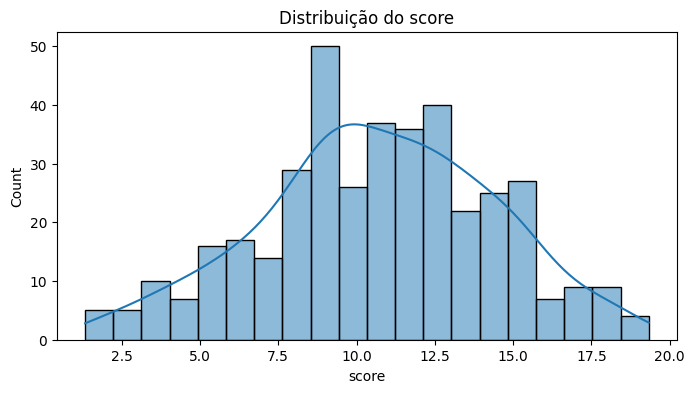

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(train['score'], kde=True, bins=20)
plt.title('Distribuição do score')
plt.show()

In [12]:
train.corr(numeric_only=True)['score'].sort_values()

,score
failures,-0.375702
goout,-0.154530
age,-0.134566
traveltime,-0.128141
Walc,-0.088042
health,-0.080333
Dalc,-0.072502
absences,-0.005978
freetime,0.003773
famrel,0.021631


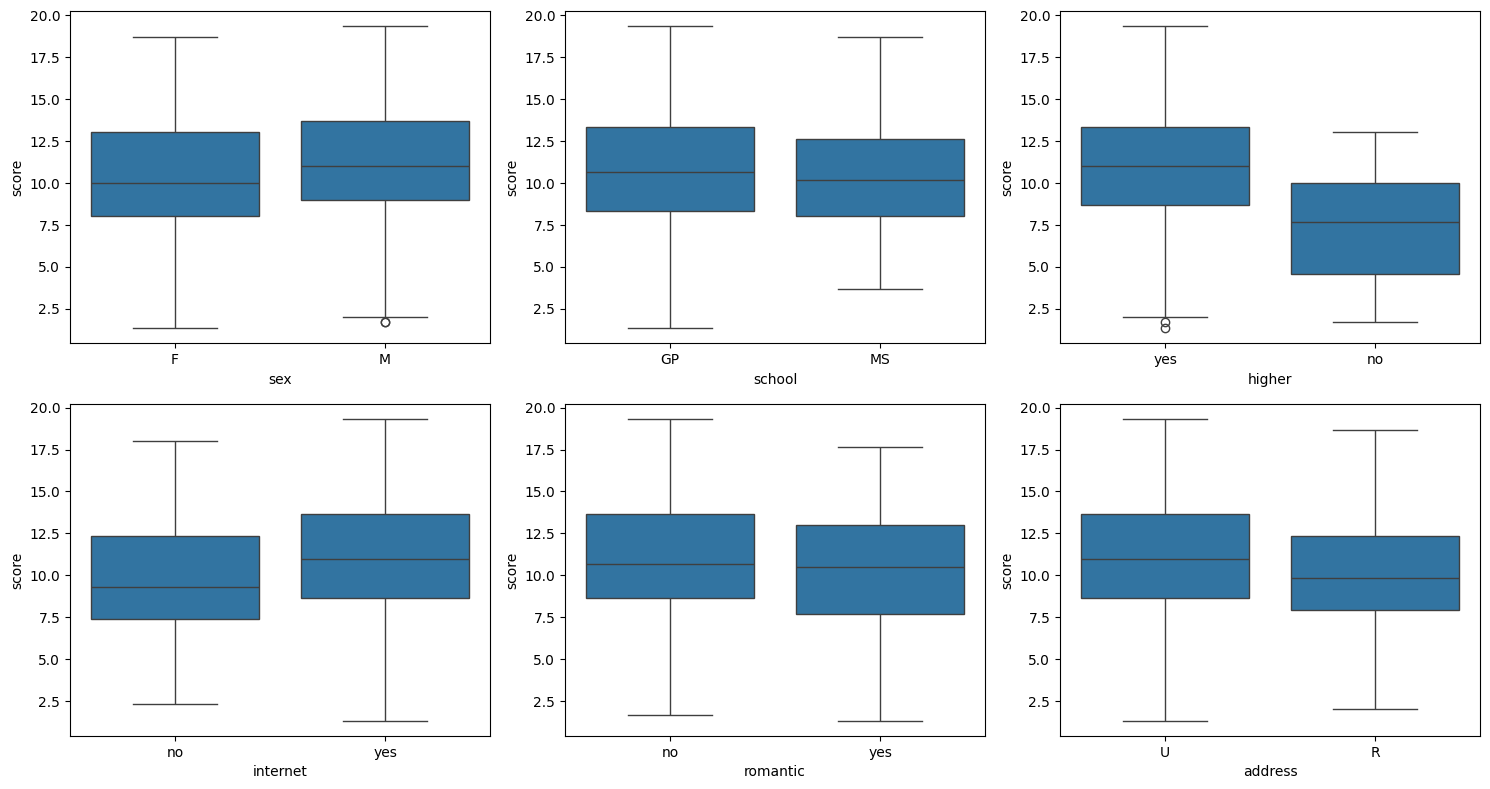

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flat, ['sex', 'school', 'higher', 'internet', 'romantic', 'address']):
    sns.boxplot(data=train, x=col, y='score', ax=ax)
plt.tight_layout()
plt.show()

In [15]:
cat_cols = ['sex', 'school', 'higher', 'internet', 'romantic', 'address']
for col in cat_cols:
    print(train[col].value_counts())
    print()

sex
F    208
M    187
Name: count, dtype: int64

school
GP    349
MS     46
Name: count, dtype: int64

higher
yes    375
no      20
Name: count, dtype: int64

internet
yes    329
no      66
Name: count, dtype: int64

romantic
no     263
yes    132
Name: count, dtype: int64

address
U    307
R     88
Name: count, dtype: int64



## Pré-processamento

### Padronização dos dados

In [17]:
train_ = train.copy()
test_ = test.copy()

train_['is_train'] = 1
test_['is_train'] = 0
test_['score'] = np.nan

full = pd.concat([train_, test_], axis=0, ignore_index=True)

full['school']    = full['school'].map({'GP': 0, 'MS': 1})
full['sex']       = full['sex'].map({'F': 0, 'M': 1})
full['address']   = full['address'].map({'U': 0, 'R': 1})
full['famsize']   = full['famsize'].map({'LE3': 0, 'GT3': 1})
full['Pstatus']   = full['Pstatus'].map({'T': 0, 'A': 1})
full['schoolsup'] = full['schoolsup'].map({'no': 0, 'yes': 1})
full['famsup']    = full['famsup'].map({'no': 0, 'yes': 1})
full['paid']      = full['paid'].map({'no': 0, 'yes': 1})
full['activities']= full['activities'].map({'no': 0, 'yes': 1})
full['nursery']   = full['nursery'].map({'no': 0, 'yes': 1})
full['higher']    = full['higher'].map({'no': 0, 'yes': 1})
full['internet']  = full['internet'].map({'no': 0, 'yes': 1})
full['romantic']  = full['romantic'].map({'no': 0, 'yes': 1})

# Nominais: one-hot
full = pd.get_dummies(full, columns=['Mjob', 'Fjob', 'reason', 'guardian'], drop_first=True)

train_processed = full[full['is_train'] == 1].drop(columns=['is_train'])
test_processed  = full[full['is_train'] == 0].drop(columns=['is_train', 'score'])

In [20]:
X = train_processed.drop(columns=['score'])
y = train_processed['score']

In [21]:
X.dtypes

,0
school,int64
sex,int64
age,int64
address,int64
famsize,int64
Pstatus,int64
Medu,int64
Fedu,int64
traveltime,int64
studytime,int64


In [22]:
X.shape

(395, 39)

## Escolha do modelo

### Primeiro treino e validação

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_val.shape)

(316, 39) (79, 39)


In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_val)

rmse = mean_squared_error(y_val, pred) ** 0.5
print(rmse)

3.3749658534076996


### Validação cruzada

In [30]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)

def rmse_cv(model, X, y):
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    return -scores

lr_scores = rmse_cv(LinearRegression(), X, y)
print('RMSE por fold:', lr_scores)
print('RMSE médio:', lr_scores.mean(), '+/-', lr_scores.std())

RMSE por fold: [3.53650477 3.34858931 3.68806667 3.24709325 3.61172737 3.12155583
 3.25646032 3.80825032 3.54142309 3.24742456]
RMSE médio: 3.4407095497247395 +/- 0.21540152622165784


### Comparação

In [32]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor

kf = KFold(n_splits=10, shuffle=True, random_state=42)

def rmse_cv(model, X, y):
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    return -scores

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'KNN': make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)), # É sensível à escala das features
    'SVR': make_pipeline(StandardScaler(), SVR(kernel='rbf')), # É sensível à escala das features
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=200),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    scores = rmse_cv(model, X, y)
    results[name] = scores.mean()
    print(f'{name}: RMSE médio = {scores.mean():.3f} (+/- {scores.std():.3f})')

LinearRegression: RMSE médio = 3.441 (+/- 0.215)
Ridge: RMSE médio = 3.424 (+/- 0.222)
Lasso: RMSE médio = 3.349 (+/- 0.344)
ElasticNet: RMSE médio = 3.331 (+/- 0.330)
KNN: RMSE médio = 3.670 (+/- 0.458)
SVR: RMSE médio = 3.358 (+/- 0.359)
DecisionTree: RMSE médio = 4.415 (+/- 0.386)
RandomForest: RMSE médio = 3.212 (+/- 0.344)
GradientBoosting: RMSE médio = 3.238 (+/- 0.302)
XGBoost: RMSE médio = 3.402 (+/- 0.353)


A Árvore de Decisão isolada teve o pior desempenho (RMSE ≈ 4.42), inclusive
abaixo do baseline de Regressão Linear (RMSE ≈ 3.44). Esse resultado é esperado: uma única árvore em um dataset pequeno como este (395 amostras) tende a se ajustar excessivamente ao treino (overfitting), perdendo capacidade de generalização. É exatamente por isso que métodos de ensemble baseados em árvores costumam superá-la — e os resultados confirmam isso: Random Forest (RMSE ≈ 3.21) e Gradient Boosting (RMSE ≈ 3.24) foram os dois melhores modelos testados, já que combinam várias árvores para reduzir a variância do modelo individual.

A diferença entre Random Forest e Gradient Boosting é pequena frente ao desvio padrão observado entre os folds (±0.34 e ±0.30, respectivamente), então os dois modelos podem ser considerados estatisticamente equivalentes nesta etapa — ambos são candidatos válidos para ajuste fino de hiperparâmetros.

Chamou atenção o XGBoost (RMSE ≈ 3.40) ter performado pior que o Gradient Boosting padrão do scikit-learn, resultado atípico já que normalmente os dois têm desempenho parecido ou o XGBoost leva vantagem. Isso provavelmente se deve aos hiperparâmetros default não estarem bem ajustados para um dataset deste tamanho — motivo pelo qual ele também foi incluído na etapa de tuning.

Entre os modelos lineares, as versões regularizadas (ElasticNet ≈ 3.33, Lasso ≈ 3.35) superaram a Regressão Linear pura (≈ 3.44) e o Ridge (≈ 3.42), sugerindo que parte das 39 features geradas no pré-processamento (especialmente após o one-hot encoding) adiciona ruído ao invés de sinal — algo que a penalização L1 (que zera coeficientes) consegue mitigar ao efetivamente descartar variáveis pouco informativas.

### Ajuste dos hiperparâmetros

#### RandomForest

In [33]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)
rf_grid.fit(X, y)
print('RandomForest melhor RMSE:', -rf_grid.best_score_)
print('Melhores params:', rf_grid.best_params_)

RandomForest melhor RMSE: 3.1897522471834927
Melhores params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}


#### GradientBoosting

In [34]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 2, 4],
}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)
gb_grid.fit(X, y)
print('GradientBoosting melhor RMSE:', -gb_grid.best_score_)
print('Melhores params:', gb_grid.best_params_)

GradientBoosting melhor RMSE: 3.1709024332295543
Melhores params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 100}


#### XGBoost

In [35]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.7, 0.85, 1.0],
}
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)
xgb_grid.fit(X, y)
print('XGBoost melhor RMSE:', -xgb_grid.best_score_)
print('Melhores params:', xgb_grid.best_params_)

XGBoost melhor RMSE: 3.16322289884364
Melhores params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.85}


#### Sobre a escolha dos hiperparâmetros nos grids

Os intervalos de valores testados no `GridSearchCV` combinam duas fontes: recomendações consolidadas na prática de cada algoritmo e ajustes heurísticos feitos considerando o tamanho reduzido deste dataset (395 amostras).

**O que vem de prática/documentação estabelecida:**
- `learning_rate: [0.01, 0.05, 0.1]` — faixa clássica para *boosting*, com `0.1` sendo o valor padrão histórico.
- `max_depth = 3` (no Gradient Boosting/XGBoost) — recomendação original de Friedman, criador do algoritmo: em *boosting*, cada árvore deve ser rasa por design (*weak learners*).
- `subsample: [0.7, 0.85, 1.0]` — faixa sugerida na própria documentação do XGBoost para amostragem estocástica.
- A ideia geral de que `n_estimators` maior tende a ajudar (ou no mínimo não piorar) em Random Forest, com ganho marginal decrescente.

**O que foi ajustado de forma heurística, sem base formal, considerando o tamanho do dataset:**
- Os valores exatos de `max_depth` no Random Forest (`None, 5, 10, 15`) e no boosting (`2, 3, 4`) — a ordem de grandeza é razoável, mas os números específicos foram escolhidos arbitrariamente para cobrir uma faixa de "raso a moderado", evitando árvores excessivamente profundas que overfitariam com poucos dados.
- `min_samples_leaf: [1, 2, 4]` — progressão escolhida arbitrariamente para evitar folhas com pouquíssimas amostras (ex.: 1 único aluno), o que seria mais arriscado num dataset pequeno.
- `n_estimators: [100, 200, 300]` — valores específicos arbitrários dentro da faixa em que se sabe que o ganho já desacelera.
- O número de valores testados por hiperparâmetro (3-4 opções, em vez de intervalos mais finos) — decisão prática para manter o tempo de execução do `GridSearchCV` razoável, sem nenhum critério estatístico por trás.

### Limitações

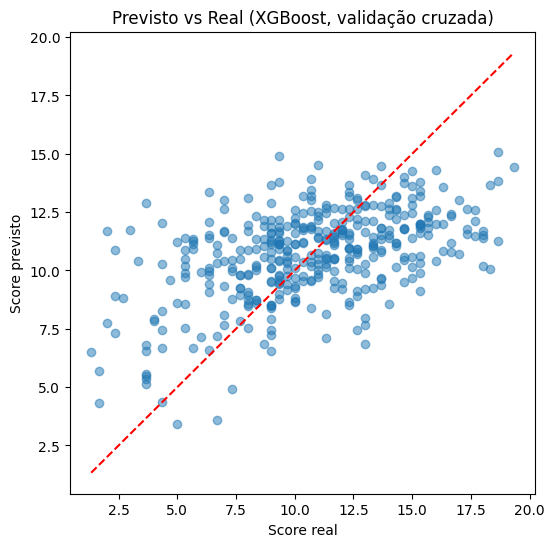

In [36]:
from sklearn.model_selection import cross_val_predict

best_xgb = XGBRegressor(**xgb_grid.best_params_, random_state=42, verbosity=0)
pred_cv = cross_val_predict(best_xgb, X, y, cv=kf)

plt.figure(figsize=(6,6))
plt.scatter(y, pred_cv, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Score real')
plt.ylabel('Score previsto')
plt.title('Previsto vs Real (XGBoost, validação cruzada)')
plt.show()

O modelo apresenta viés de regressão à média: tende a superestimar scores muito baixos e subestimar scores muito altos, refletindo a escassez desses casos extremos no conjunto de treino.

## Modelo Final

In [37]:
final_model = XGBRegressor(**xgb_grid.best_params_, random_state=42, verbosity=0)
final_model.fit(X, y)

test_pred = final_model.predict(test_processed)

# checagem rápida: notas devem estar entre 0 e 20
print(test_pred.min(), test_pred.max())

4.9352303 13.810931


### Submissão

In [40]:
submission = pd.DataFrame({
    'id': range(len(test_pred)),   # 0, 1, 2, ..., 39
    'score': test_pred
})
submission.to_csv('submission_regressao.csv', index=False)
submission.head()

,id,score
0,0,12.945167
1,1,12.636041
2,2,6.765693
3,3,11.490790
4,4,11.660206


In [41]:
print(submission.shape)                  # deve ser (40, 2), batendo com test.csv
print(submission.isnull().sum().sum())   # deve ser 0
print(submission['score'].min(), submission['score'].max())  # deve estar entre 0 e 20

(40, 2)
0
4.935230255126953 13.810931205749512


# Classificação - Breast Cancer

In [2]:
train2 = pd.read_csv('train2.csv')
test2 = pd.read_csv('test2.csv')

## EDA

### Primeira Análise

In [4]:
train2.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [6]:
train2.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
train2.shape

(569, 31)

In [8]:
train2.isna().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


### Distribuições e correlações

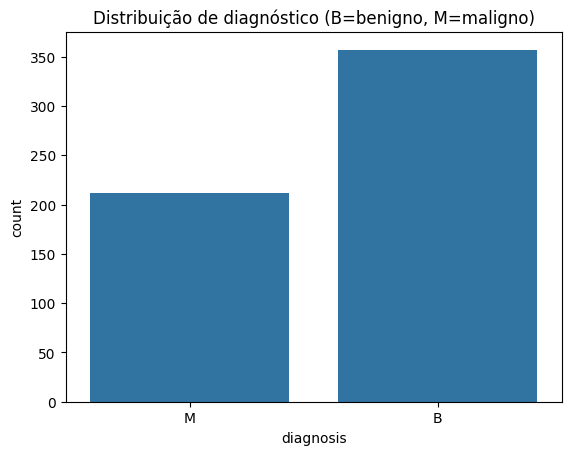

In [3]:
sns.countplot(data=train2, x='diagnosis')
plt.title('Distribuição de diagnóstico (B=benigno, M=maligno)')
plt.show()

In [9]:
train2_temp = train2.copy()
train2_temp['diagnosis_num'] = train2_temp['diagnosis'].map({'B': 0, 'M': 1})

corr_target = train2_temp.corr(numeric_only=True)['diagnosis_num'].sort_values(ascending=False)
print(corr_target)

diagnosis_num              1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

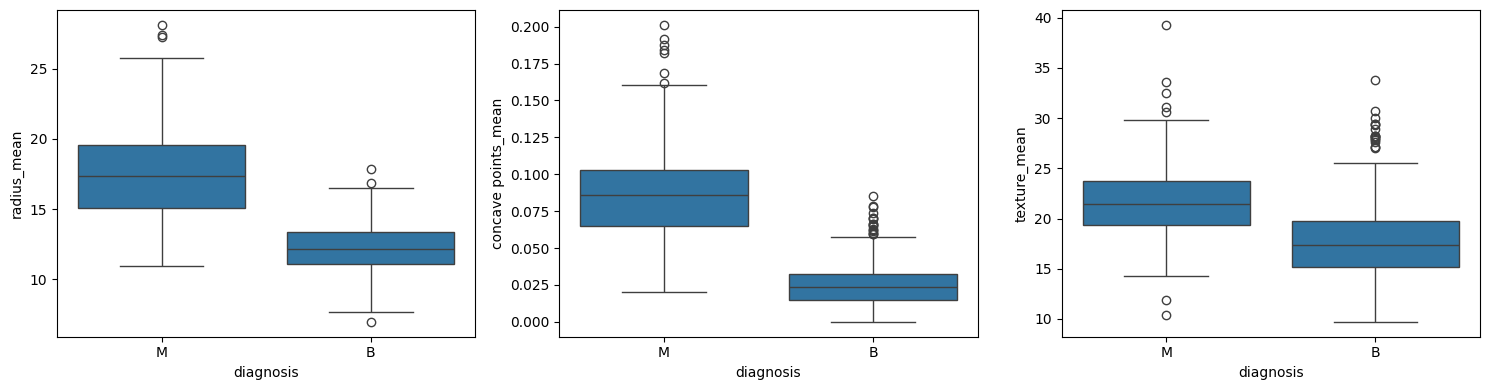

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['radius_mean', 'concave points_mean', 'texture_mean']):
    sns.boxplot(data=train2, x='diagnosis', y=col, ax=ax)
plt.tight_layout()
plt.show()

In [11]:
cols_check = ['radius_mean', 'perimeter_mean', 'area_mean']
print(train2[cols_check].corr())

                radius_mean  perimeter_mean  area_mean
radius_mean        1.000000        0.997855   0.987357
perimeter_mean     0.997855        1.000000   0.986507
area_mean          0.987357        0.986507   1.000000


As features `radius`, `perimeter` e `area` (em suas versões `mean`, se e `worst`) são fortemente correlacionadas entre si por definição geométrica, o que gera redundância mas não impede o uso dos modelos testados.

## Pré-processamento

### Padronização

Como as features são todas `float64`, só é necessário padronizar o alvo `diagnosis`.

In [12]:
train2_proc = train2.copy()
test2_proc = test2.copy()

train2_proc['diagnosis'] = train2_proc['diagnosis'].map({'B': 0, 'M': 1})

X2 = train2_proc.drop(columns=['diagnosis'])
y2 = train2_proc['diagnosis']

print(X2.shape, y2.shape)
print(X2.dtypes.value_counts())
print(X2.isnull().sum().sum())

(569, 30) (569,)
float64    30
Name: count, dtype: int64
0


## Escolha do modelo

### Primeiro treino e validação

In [15]:
from sklearn.model_selection import train_test_split

X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2 # Classes desbalanceadas
)
print(X2_train.shape, X2_val.shape)
print(y2_train.value_counts(normalize=True))
print(y2_val.value_counts(normalize=True))

(455, 30) (114, 30)
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


Acurácia: 0.9649122807017544


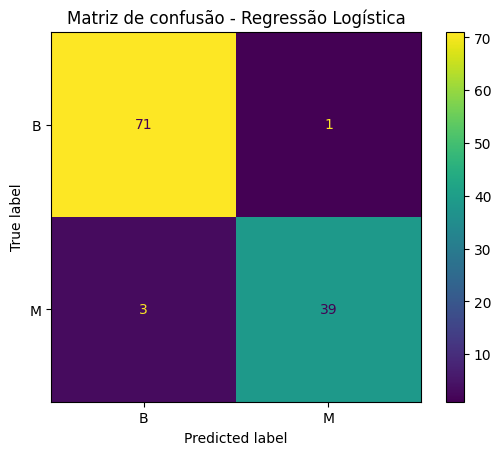

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)) # Padronização por conta das diferentes escalas
log_reg.fit(X2_train, y2_train)
pred2 = log_reg.predict(X2_val)

acc = accuracy_score(y2_val, pred2)
print('Acurácia:', acc)

cm = confusion_matrix(y2_val, pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['B', 'M'])
disp.plot()
plt.title('Matriz de confusão - Regressão Logística')
plt.show()

Métrica que, clinicamente, muitas vezes importa mais que a acurácia geral:

In [17]:
recall_M = 39 / (39 + 3)
print(f'Recall (sensibilidade) para maligno: {recall_M:.3f}')

Recall (sensibilidade) para maligno: 0.929


### Validação cruzada e comparação

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def acc_cv(model, X, y):
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    return scores

models2 = {
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'NaiveBayes': GaussianNB(),
    'SVM_linear': make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True, random_state=42)),
    'SVM_rbf': make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42)),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_estimators=200),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss')
}

results2 = {}
for name, model in models2.items():
    scores = acc_cv(model, X2, y2)
    results2[name] = scores.mean()
    print(f'{name}: Acurácia média = {scores.mean():.4f} (+/- {scores.std():.4f})')

LogisticRegression: Acurácia média = 0.9754 (+/- 0.0195)
KNN: Acurácia média = 0.9701 (+/- 0.0176)
NaiveBayes: Acurácia média = 0.9368 (+/- 0.0305)
SVM_linear: Acurácia média = 0.9719 (+/- 0.0251)
SVM_rbf: Acurácia média = 0.9754 (+/- 0.0195)
DecisionTree: Acurácia média = 0.9262 (+/- 0.0233)
RandomForest: Acurácia média = 0.9526 (+/- 0.0333)
GradientBoosting: Acurácia média = 0.9614 (+/- 0.0219)
XGBoost: Acurácia média = 0.9631 (+/- 0.0288)


Aqui os modelos lineares e baseados em margem — **Regressão Logística** e **SVM com kernel RBF** (ambos com acurácia média ≈ 0.9754) — superaram os *ensembles* baseados em árvore. Isso é um indício importante sobre a estrutura do problema: as classes maligno/benigno são quase linearmente separáveis no espaço das 30 features, não exigindo fronteiras de decisão muito complexas. Esse resultado está alinhado com o que já havia sido observado na EDA, onde os boxplots mostravam separação nítida entre os grupos M e B, com pouca sobreposição.

Reforça essa leitura o fato de o **SVM com kernel RBF ter empatado com o SVM linear** — se a fronteira de decisão real fosse fortemente não linear, seria esperado que o kernel RBF (capaz de capturar essas relações) superasse claramente a versão linear, o que não aconteceu.

A **Árvore de Decisão** isolada foi novamente o pior modelo (acurácia ≈ 0.9262), repetindo o padrão observado na regressão: uma única árvore tende a overfitar, e por isso costuma perder para *ensembles* e para modelos lineares bem ajustados.

Chama atenção que o **Random Forest teve desempenho inferior ao Gradient Boosting e ao XGBoost** aqui (≈ 0.9526 vs ≈ 0.96), um resultado **oposto** ao observado na Parte 1, onde Random Forest foi o melhor modelo. Na regressão, relações mais fracas e não lineares favoreceram o *bagging*; aqui, uma separação quase linear favorece modelos lineares e de margem.

Por fim, mesmo o **Naive Bayes** — o modelo mais simples da comparação, que assume independência entre as features (premissa violada aqui, dada a forte correlação entre `radius`, `perimeter` e `area`) — atingiu acurácia de 0.9368, evidenciando que o sinal presente nas features é forte o suficiente para que até um classificador ingênuo tenha bom desempenho.

### Ajuste dos hiperparâmetros

#### Regressão logística

In [19]:
from sklearn.model_selection import GridSearchCV

logreg_params = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l2'],
}
logreg_grid = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    logreg_params, cv=skf, scoring='accuracy', n_jobs=-1
)
logreg_grid.fit(X2, y2)
print('LogisticRegression melhor acurácia:', logreg_grid.best_score_)
print('Melhores params:', logreg_grid.best_params_)

LogisticRegression melhor acurácia: 0.9771929824561403
Melhores params: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2'}


#### SVM com kernel RBF

In [20]:
svm_params = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.001],
}
svm_grid = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42)),
    svm_params, cv=skf, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X2, y2)
print('SVM melhor acurácia:', svm_grid.best_score_)
print('Melhores params:', svm_grid.best_params_)

SVM melhor acurácia: 0.9771929824561403
Melhores params: {'svc__C': 10, 'svc__gamma': 'scale'}


#### XGBoost

In [21]:
xgb2_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.7, 0.85, 1.0],
}
xgb2_grid = GridSearchCV(
    XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
    xgb2_params, cv=skf, scoring='accuracy', n_jobs=-1
)
xgb2_grid.fit(X2, y2)
print('XGBoost melhor acurácia:', xgb2_grid.best_score_)
print('Melhores params:', xgb2_grid.best_params_)

XGBoost melhor acurácia: 0.968421052631579
Melhores params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.85}


#### Sobre a escolha dos hiperparâmetros nos grids (classificação)

Assim como na Parte 1, os intervalos testados combinam faixas consolidadas na prática de cada algoritmo com ajustes heurísticos considerando o tamanho do dataset (569 amostras).

**O que vem de prática/documentação estabelecida:**
- `logisticregression__C: [0.01, 0.1, 1, 10, 100]` — progressão logarítmica (cada valor é 10× o anterior) é a forma padrão de explorar o parâmetro de regularização em modelos lineares, já que o efeito de `C` é multiplicativo, não aditivo — variar em escala linear (ex: 1, 2, 3...) deixaria a busca ineficiente, cobrindo pouco range útil.
- `svc__gamma: ['scale', 0.01, 0.001]` — `'scale'` é o valor default recomendado pela documentação do scikit-learn (calcula automaticamente com base na variância dos dados) e costuma ser um bom ponto de partida; os demais valores seguem a mesma lógica logarítmica do `C`.
- `learning_rate: [0.01, 0.05, 0.1]` (XGBoost) — mesma faixa clássica de *boosting* usada na Parte 1, com `0.1` como padrão histórico.
- `max_depth: [2, 3, 4]` (XGBoost) — segue a recomendação de Friedman de árvores rasas em *boosting*, mesma faixa usada na regressão.
- `subsample: [0.7, 0.85, 1.0]` — faixa sugerida na documentação oficial do XGBoost para amostragem estocástica.

**O que foi ajustado de forma heurística, sem base formal, considerando o tamanho do dataset:**
- `svc__C: [0.1, 1, 10, 100]` — a lógica logarítmica é padrão, mas o range específico (começar em 0.1 e não em 0.001, por exemplo) foi escolha arbitrária, pensando em não testar regularizações extremas desnecessárias para um dataset de porte médio (569 amostras).
- `n_estimators: [100, 200, 300]` (XGBoost) — mesmos valores arbitrários usados na Parte 1, dentro da faixa em que o ganho marginal já desacelera.
- O número de valores testados por hiperparâmetro (3-5 opções) — decisão prática para manter o tempo de execução do `GridSearchCV` razoável, sem critério estatístico por trás.
- A ausência de `penalty: ['l1', 'l2']` no grid da Regressão Logística (fixei em `'l2'`) — simplificação arbitrária para reduzir o espaço de busca; testar `l1` também seria válido, mas exigiria trocar o `solver` padrão (que não suporta L1), o que aumentaria a complexidade do grid sem garantia de ganho relevante para este problema.

Como na Parte 1, essas escolhas não garantem a combinação globalmente ótima — exploram uma vizinhança plausível dos valores default, adaptada ao porte do problema.

Como empataram tecnicamente, o desempate pode ser por interpretabilidade — Regressão Logística. Pra um problema clínico, interpretabilidade tem valor real (médicos/pesquisadores querem entender o "porquê").

### Limitações

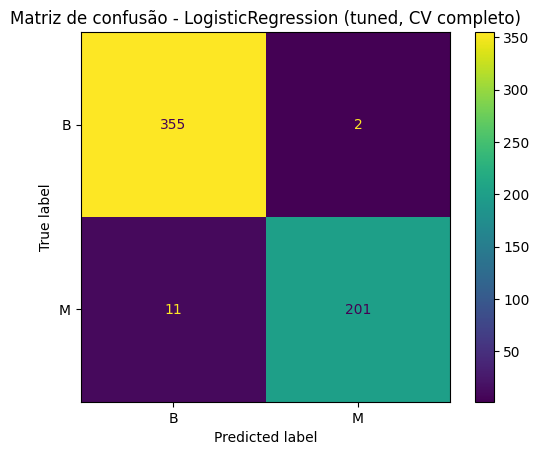

Acurácia: 0.9771528998242531


In [22]:
from sklearn.model_selection import cross_val_predict

best_logreg = make_pipeline(StandardScaler(), LogisticRegression(
    C=logreg_grid.best_params_['logisticregression__C'],
    max_iter=1000, random_state=42
))
pred_cv2 = cross_val_predict(best_logreg, X2, y2, cv=skf)

cm2 = confusion_matrix(y2, pred_cv2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['B', 'M'])
disp2.plot()
plt.title('Matriz de confusão - LogisticRegression (tuned, CV completo)')
plt.show()

print('Acurácia:', accuracy_score(y2, pred_cv2))

O modelo foi otimizado para acurácia, que trata falso positivo (FP) e falso negativo (FN) como igualmente custosos. Clinicamente isso não é verdade: um FP gera exames extras desnecessários, enquanto um FN (11 dos 212 casos malignos, aqui) significa deixar um câncer sem diagnóstico — um erro muito mais grave. Uma abordagem clínica real ajustaria o *threshold* de decisão do modelo para reduzir falsos negativos, mesmo à custa de mais falsos positivos.

In [26]:
recall_M = 201 / (201 + 11)
print(f'Recall (sensibilidade) para maligno do algoritmo: {recall_M:.3f}')

Recall (sensibilidade) para maligno do algoritmo: 0.948


## Modelo final

In [27]:
final_clf = make_pipeline(StandardScaler(), LogisticRegression(
    C=logreg_grid.best_params_['logisticregression__C'],
    max_iter=1000, random_state=42
))
final_clf.fit(X2, y2)

test2_pred = final_clf.predict(test2)  # já sai como 0/1

print(pd.Series(test2_pred).value_counts())

0    28
1    12
Name: count, dtype: int64


### Submissão

In [28]:
submission2 = pd.DataFrame({
    'id': range(len(test2_pred)),
    'diagnosis': test2_pred
})
submission2.to_csv('submission_classificacao.csv', index=False)
submission2.head()

,id,diagnosis
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0


In [29]:
print(submission2.shape)
print(submission2.isnull().sum().sum())
print(submission2['diagnosis'].unique())

(40, 2)
0
[0 1]
